Experiment A: Confidence Analysis of Random Forest

Research Question

Can Random Forest confidence distinguish reliable predictions from uncertain predictions?

Hypothesis

Unknown attacks that are misclassified by Random Forest are expected to have lower confidence than correctly classified samples.

Objective

Analyze Random Forest confidence.
Study confidence distribution.
Determine whether confidence can be used for Hybrid IDS routing.

In [4]:
# ============================================
# Experiment A: Random Forest Confidence Analysis
# ============================================

import os
import joblib
import numpy as np
import pandas as pd

from sklearn.metrics import confusion_matrix

In [5]:
# Path to the trained Random Forest model

model_path = "models/random_forest_unknown.pkl"

# Check if the model exists

print("Model exists:", os.path.exists(model_path))

# Load the model

rf = joblib.load(model_path)

print("\nModel loaded successfully!\n")
print(rf)

Model exists: True

Model loaded successfully!

RandomForestClassifier(class_weight='balanced', max_depth=20, n_jobs=-1,
                       random_state=42)


In [7]:
# ============================================
# Load Unknown Test Dataset
# ============================================

import numpy as np
import pandas as pd

# Load features
X_test = np.load("processed/x_test_scaled.npy")

# Load labels
y_test = np.load("processed/y_test.npy")

print("X_test Shape :", X_test.shape)
print("y_test Shape :", y_test.shape)

print("\nUnique Labels:")
print(np.unique(y_test))

print("\nFirst 10 Labels:")
print(y_test[:10])

X_test Shape : (504160, 78)
y_test Shape : (504160,)

Unique Labels:
[0 1]

First 10 Labels:
[0 0 1 1 0 0 0 0 0 0]


In [4]:
print("Total samples:", len(y_test))

unique, counts = np.unique(y_test, return_counts=True)

print("\nLabel Distribution:")
for label, count in zip(unique, counts):
    print(f"Label {label}: {count}")

Total samples: 504160

Label Distribution:
Label 0: 419012
Label 1: 85148


In [8]:
unknown_test = pd.read_csv("processed/unknown_test.csv")

print(unknown_test.shape)
print(unknown_test["Label"].value_counts())

(25122, 79)
Label
BENIGN              12561
DoS slowloris        5385
DoS Slowhttptest     5228
Bot                  1948
Name: count, dtype: int64


In [9]:
unknown_test = pd.read_csv("processed/unknown_test.csv")

unknown_test.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,25122.000000,2.512200e+04,25122.000000,25122.000000,25122.000000,2.512200e+04,25122.000000,25122.000000,25122.000000,25122.000000,...,25122.000000,25122.000000,2.512200e+04,2.512200e+04,2.512200e+04,2.512200e+04,2.512200e+04,2.512200e+04,2.512200e+04,2.512200e+04
mean,6437.563450,3.183420e+07,7.317769,5.571053,798.677096,6.268784e+03,203.620134,20.739869,73.811667,69.188251,...,3.593305,29.564047,1.176418e+06,4.419762e+05,1.518121e+06,8.607138e+05,1.481740e+07,3.016788e+06,1.887305e+07,1.241404e+07
std,16379.842478,4.331643e+07,131.749950,170.990730,5753.602876,3.817584e+05,841.734550,95.562259,240.424403,271.441520,...,116.751438,7.322974,2.395052e+06,1.486901e+06,2.966913e+06,2.261205e+06,3.030360e+07,6.796204e+06,3.233764e+07,3.028360e+07
min,0.000000,-1.000000e+00,1.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,80.000000,2.419325e+04,2.000000,1.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,80.000000,2.999890e+06,3.000000,2.000000,54.000000,6.000000e+00,35.000000,0.000000,32.000000,0.000000,...,1.000000,32.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,443.000000,6.313261e+07,7.000000,3.000000,371.000000,1.660000e+02,231.000000,8.000000,59.750000,95.541876,...,3.000000,32.000000,1.165026e+05,0.000000e+00,2.287625e+05,7.430000e+02,1.870000e+07,0.000000e+00,3.210000e+07,8.008197e+06
max,65490.000000,1.199994e+08,18649.000000,25335.000000,207930.000000,5.610000e+07,23360.000000,1983.000000,5940.857143,7049.469004,...,18392.000000,44.000000,2.060000e+07,2.570000e+07,5.430000e+07,1.670000e+07,1.200000e+08,7.170000e+07,1.200000e+08,1.200000e+08


In [10]:
from sklearn.preprocessing import StandardScaler

In [11]:
import sklearn 
print(sklearn.__version__)

1.9.0


In [13]:
# ============================================
# Load Unknown Test Dataset
# ============================================

import numpy as np

X_unknown = np.load("processed/x_test_unknown.npy")
y_unknown = np.load("processed/y_test_unknown.npy")

print("X_unknown Shape :", X_unknown.shape)
print("y_unknown Shape :", y_unknown.shape)

print("\nUnique Labels:")
print(np.unique(y_unknown))

print("\nFirst 10 Labels:")
print(y_unknown[:10])

X_unknown Shape : (25122, 78)
y_unknown Shape : (25122,)

Unique Labels:
[0 1]

First 10 Labels:
[1 1 1 1 1 1 1 1 1 1]


In [14]:
# ============================================
# Cell 3 : Load Unknown Attack Dataset
# ============================================

import numpy as np

# Load unknown attack dataset
X_unknown = np.load("processed/x_test_unknown.npy")
y_unknown = np.load("processed/y_test_unknown.npy")

print("=" * 50)
print("Unknown Test Dataset Loaded Successfully")
print("=" * 50)

print("Feature Shape :", X_unknown.shape)
print("Label Shape   :", y_unknown.shape)

print("\nUnique Labels :", np.unique(y_unknown))

print("\nFirst 10 Labels:")
print(y_unknown[:10])

Unknown Test Dataset Loaded Successfully
Feature Shape : (25122, 78)
Label Shape   : (25122,)

Unique Labels : [0 1]

First 10 Labels:
[1 1 1 1 1 1 1 1 1 1]


In [15]:
# ============================================
# Cell 4 : Random Forest Predictions
# ============================================

# Predict class labels
y_pred = rf.predict(X_unknown)

print("=" * 50)
print("Prediction Completed")
print("=" * 50)

print("Prediction Shape :", y_pred.shape)

print("\nFirst 20 Predictions:")
print(y_pred[:20])

print("\nPrediction Distribution:")
unique, counts = np.unique(y_pred, return_counts=True)

for label, count in zip(unique, counts):
    print(f"Class {label}: {count}")

Prediction Completed
Prediction Shape : (25122,)

First 20 Predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

Prediction Distribution:
Class 0: 23269
Class 1: 1853


In [16]:
# ============================================
# Cell 5 : Prediction Probabilities
# ============================================

# Get prediction probabilities
y_prob = rf.predict_proba(X_unknown)

print("=" * 50)
print("Prediction Probabilities Generated")
print("=" * 50)

print("Shape :", y_prob.shape)

print("\nFirst 5 Probability Vectors:")
print(y_prob[:5])

Prediction Probabilities Generated
Shape : (25122, 2)

First 5 Probability Vectors:
[[1.00000000e+00 0.00000000e+00]
 [1.00000000e+00 0.00000000e+00]
 [9.99996102e-01 3.89758464e-06]
 [9.99907484e-01 9.25156577e-05]
 [9.99996102e-01 3.89758464e-06]]


In [17]:
# ============================================
# Cell 6 : Extract Confidence Scores
# ============================================

# Confidence = highest predicted probability
confidence = np.max(y_prob, axis=1)

print("=" * 50)
print("Confidence Scores Generated")
print("=" * 50)

print("Number of confidence scores :", len(confidence))

print("\nFirst 10 confidence scores:")
print(confidence[:10])

print("\nConfidence Statistics")
print("----------------------")
print("Minimum :", confidence.min())
print("Maximum :", confidence.max())
print("Mean    :", confidence.mean())
print("Median  :", np.median(confidence))

Confidence Scores Generated
Number of confidence scores : 25122

First 10 confidence scores:
[1.         1.         0.9999961  0.99990748 0.9999961  0.99993336
 0.99998837 0.99999167 0.99992271 0.99994277]

Confidence Statistics
----------------------
Minimum : 0.5
Maximum : 1.0
Mean    : 0.923400450642847
Median  : 0.9999521399956877


In [18]:
# ============================================
# Cell 7 : Create Confidence Analysis DataFrame
# ============================================

# Create analysis DataFrame
analysis_df = pd.DataFrame({
    "Actual": y_unknown,
    "Predicted": y_pred,
    "Confidence": confidence
})

# Assign TP, TN, FP, FN
def get_category(actual, predicted):
    if actual == 1 and predicted == 1:
        return "TP"
    elif actual == 0 and predicted == 0:
        return "TN"
    elif actual == 0 and predicted == 1:
        return "FP"
    else:
        return "FN"

analysis_df["Category"] = analysis_df.apply(
    lambda row: get_category(row["Actual"], row["Predicted"]),
    axis=1
)

print("=" * 60)
print("Confidence Analysis DataFrame")
print("=" * 60)

print(analysis_df.head())

print("\nCategory Counts:")
print(analysis_df["Category"].value_counts())

Confidence Analysis DataFrame
   Actual  Predicted  Confidence Category
0       1          0    1.000000       FN
1       1          0    1.000000       FN
2       1          0    0.999996       FN
3       1          0    0.999907       FN
4       1          0    0.999996       FN

Category Counts:
Category
TN    12554
FN    10715
TP     1846
FP        7
Name: count, dtype: int64


In [19]:
# ============================================
# Cell 8 : Save Confidence Analysis
# ============================================

import os

os.makedirs("results", exist_ok=True)

analysis_df.to_csv(
    "results/rf_confidence_analysis.csv",
    index=False
)

print("✅ File saved successfully!")

✅ File saved successfully!


In [20]:
# ============================================
# Cell 9 : Confidence Statistics by Category
# ============================================

confidence_stats = (
    analysis_df
    .groupby("Category")["Confidence"]
    .agg([
        "count",
        "mean",
        "median",
        "std",
        "min",
        "max"
    ])
    .round(6)
)

print("=" * 60)
print("Confidence Statistics by Category")
print("=" * 60)

print(confidence_stats)

Confidence Statistics by Category
          count      mean    median       std       min       max
Category                                                         
FN        10715  0.881348  0.959877  0.142149  0.500000  1.000000
FP            7  0.780766  0.855661  0.199789  0.523273  0.980323
TN        12554  0.999122  1.000000  0.009270  0.577538  1.000000
TP         1846  0.653072  0.670000  0.100530  0.500379  1.000000


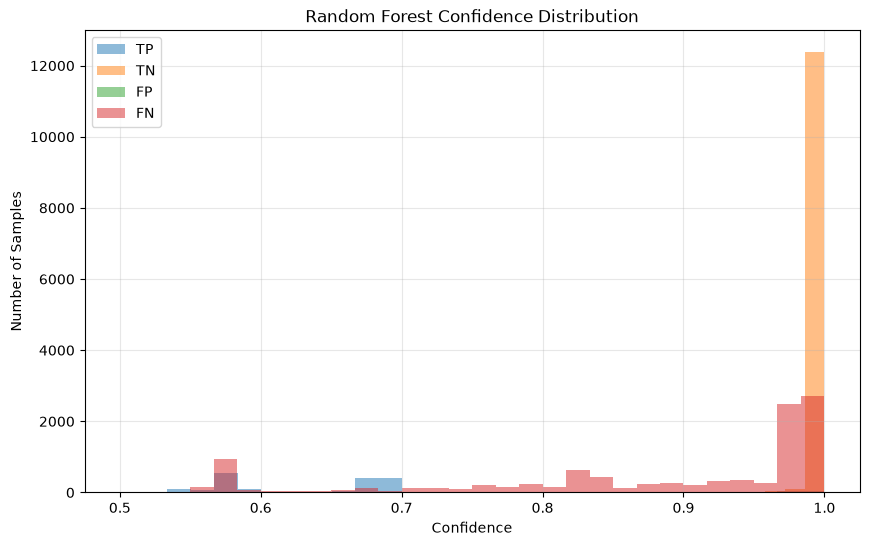

In [21]:
# ============================================
# Cell 10 : Confidence Histogram
# ============================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

categories = ["TP", "TN", "FP", "FN"]

for category in categories:
    subset = analysis_df[analysis_df["Category"] == category]

    plt.hist(
        subset["Confidence"],
        bins=30,
        alpha=0.5,
        label=category
    )

plt.title("Random Forest Confidence Distribution")
plt.xlabel("Confidence")
plt.ylabel("Number of Samples")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

<Figure size 800x600 with 0 Axes>

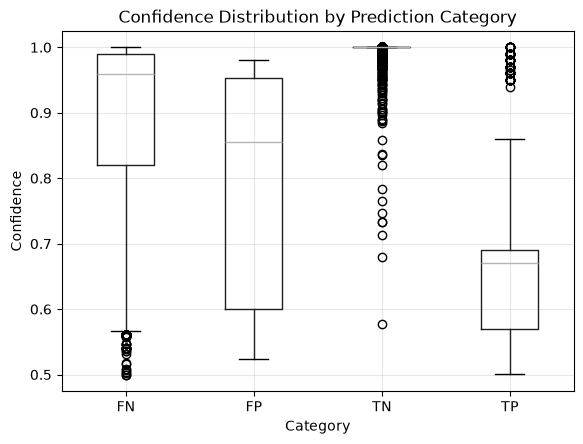

In [22]:
# ============================================
# Cell 11 : Confidence Boxplot
# ============================================

plt.figure(figsize=(8,6))

analysis_df.boxplot(
    column="Confidence",
    by="Category"
)

plt.title("Confidence Distribution by Prediction Category")
plt.suptitle("")

plt.xlabel("Category")
plt.ylabel("Confidence")

plt.grid(alpha=0.3)

plt.show()

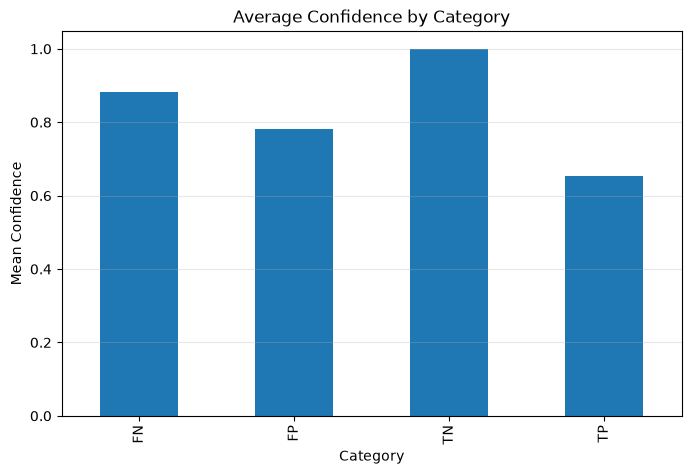

In [23]:
# ============================================
# Cell 12 : Mean Confidence Comparison
# ============================================

mean_confidence = (
    analysis_df
    .groupby("Category")["Confidence"]
    .mean()
)

plt.figure(figsize=(8,5))

mean_confidence.plot(
    kind="bar"
)

plt.title("Average Confidence by Category")
plt.ylabel("Mean Confidence")
plt.xlabel("Category")

plt.grid(axis="y", alpha=0.3)

plt.show()

Research Interpretation

Create a Markdown cell (not code) and write:

Experiment A Findings

Research Question

Can Random Forest confidence distinguish reliable predictions from uncertain predictions?

Observations

True Negatives achieved the highest average confidence (0.9991), indicating that Random Forest is highly confident when correctly identifying benign traffic.
True Positives achieved a comparatively low average confidence (0.6531), suggesting that successful detection of unknown attacks is often accompanied by uncertainty.
False Negatives showed a high average confidence (0.8813), indicating that the model frequently misclassified unknown attacks as benign while remaining highly confident.
False Positives were limited in number (7 samples), making them insufficient for strong statistical conclusions.

Conclusion

The experiment demonstrates that Random Forest confidence alone cannot reliably distinguish correct predictions from incorrect predictions on unknown attacks. Consequently, a confidence-only routing strategy is unlikely to provide robust unknown attack detection. Additional decision criteria, such as anomaly scores or uncertainty measures, should be incorporated into the proposed Hybrid IDS.